# Lab 4: LLM Fine-Tuning and Inference

Please fill in the following information in the code cell below (make sure to run it too).

In [1]:
#STUDENT_NAME = '<insert name here>'
#STUDENT_EMAIL = '<insert email here>'
#STUDENT_ID = '<insert student id here>'
STUDENT_NAME = 'Tony Chen'
STUDENT_EMAIL = 'guanlin.chen@rotman.utoronto.ca'
STUDENT_ID = '1007822260'

assert STUDENT_NAME != '<insert name here>'
assert STUDENT_EMAIL != '<insert email here>'
assert STUDENT_ID != '<insert student id here>'

print(f"Name: {STUDENT_NAME}")
print(f"Email: {STUDENT_EMAIL}")
print(f"Student ID: {STUDENT_ID}")

Name: Tony Chen
Email: guanlin.chen@rotman.utoronto.ca
Student ID: 1007822260


## Introduction

Welcome to Lab 4! In this session, you'll gain deeper knowledge into LLM training, fine-tuning, and inference.

You will:

1.   Implement the self-supervised pre-training objective
2.   Fine-tune a causal LLM with LoRa
3.   Implement and experiment with different generation strategies

By the end of this lab, you will better understand how to relate the original pre-training of LLMs to their actual utilization.

## 0. Environment Setup

> If you're on a managed environment (e.g., Colab or a lab VM), run the installs below. If packages are preinstalled, you can skip the `pip install` cell.

In [1]:
%pip install -q transformers datasets accelerate

## Section 1 – Causal Language Model Pre-Training (18 Marks)

In this section you will implement the **self-supervised pre-training objective** for causal language models from scratch.

Given a sequence of tokens, the model will learn to predict the next token at every position. The labels come directly from the input.

Objectives:
1. Understand what the model outputs at each step and how labels are constructed
2. Implement the cross-entropy loss manually
3. Write a minimal training loop and observe the loss decreasing
4. Compare the base model (before training) to the fine-tuned model on held-out text
5. Inspect what the model has and hasn't learned


### 1.0 Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_NAME = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token   # GPT-2 has no pad token by default
print(f"Vocabulary size: {tokenizer.vocab_size:,}")


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocabulary size: 50,257


### 1.1 The Self-Supervised Objective (3 Marks)

Lecture Slide 6 shows the key insight:

> **data:** `When life gives you lemons, make lemonade`
>
> **input:** `When life gives you lemons, make`  → **label:** `lemonade`
>
> **input:** `When life gives you lemons,`        → **label:** `make`
>
> **input:** `When life gives you`                → **label:** `lemons`

From one sentence we get one training example per token without needing human annotation.

Run the cell below to see this concretely with GPT-2's tokenizer.


In [3]:
sentence = "When life gives you lemons, make lemonade."
token_ids = tokenizer.encode(sentence)
tokens    = tokenizer.convert_ids_to_tokens(token_ids)

print(f"{'Position':<10} {'Input token':<20} {'Label token (next)'}")
print("-" * 52)
for i, (tok, tok_id) in enumerate(zip(tokens, token_ids)):
    label_tok = tokens[i + 1] if i + 1 < len(tokens) else "<END>"
    print(f"{i:<10} {repr(tok):<20} {repr(label_tok)}")


Position   Input token          Label token (next)
----------------------------------------------------
0          'When'               'Ġlife'
1          'Ġlife'              'Ġgives'
2          'Ġgives'             'Ġyou'
3          'Ġyou'               'Ġle'
4          'Ġle'                'mons'
5          'mons'               ','
6          ','                  'Ġmake'
7          'Ġmake'              'Ġlemon'
8          'Ġlemon'             'ade'
9          'ade'                '.'
10         '.'                  '<END>'


In [ ]:
token_ids_tensor = torch.tensor(token_ids)
inputs_demo = token_ids_tensor[:-1]
labels_demo = token_ids_tensor[1:]

print("inputs:", tokenizer.convert_ids_to_tokens(inputs_demo.tolist()))
print("labels:", tokenizer.convert_ids_to_tokens(labels_demo.tolist()))
print(f"\n{len(inputs_demo)} training pairs from one sentence of {len(token_ids)} tokens")


inputs: ['When', 'Ġlife', 'Ġgives', 'Ġyou', 'Ġle', 'mons', ',', 'Ġmake', 'Ġlemon', 'ade']
labels: ['Ġlife', 'Ġgives', 'Ġyou', 'Ġle', 'mons', ',', 'Ġmake', 'Ġlemon', 'ade', '.']

10 training pairs from one sentence of 11 tokens


**Questions (3 Marks)**

1. How many tokens does the sentenced have? How many (input, label) training pairs does
   it produce? Why is this relationship between sentence length and training
   pairs useful when scaling to billions of tokens of training data?

   The sentence has 11 tokens and 10 training pairs.  This is useful at large scale because a single unlabeled text sequence automatically generates many training examples, so billions of tokens of raw text turn directly into massive numbers of prediction targets.


2. Why is this called *self-supervised* rather than *supervised* learning?
   What would need to change to make it supervised?

   Because the supervision signal comes from the data itself, where the next token in the sentence is the label, so no human has to annotate anything. To make it supervised, we would need externally provided labels, such as humans assigning categories, answers, or desired outputs for each input.

3. Why, in practice, you wouldn't train a LLM with an input consisting of just one token?

   Because this would give almost no context for the LLM. Language meaning depends heavily on previous words, so very short contexts do not teach the model how words interact across longer passages.



### 1.2 The Cross-Entropy Loss (5 Marks)

At each position the model outputs a **probability distribution over the full
vocabulary**. The training objective is to maximise the
probability assigned to the correct next token which is equivalent to minimising the
**cross-entropy** between the model's distribution and a one-hot distribution
over the correct token.

Cross-entropy loss at position t:

$$\mathcal{L}_t = -\log p_{\theta}(x_{t+1} \mid x_1, \ldots, x_t)$$

The total loss is the mean over all positions.

In this section you will compute this loss manually so you can see exactly what
the model is minimising.


In [4]:
# Load GPT-2 and run a forward pass on a short sentence
model_gpt2 = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model_gpt2.eval()

sentence   = "When life gives you lemons, make lemonade"
input_ids  = tokenizer.encode(sentence, return_tensors="pt").to(device)  # (1, seq_len)

with torch.no_grad():
    outputs = model_gpt2(input_ids=input_ids)

logits = outputs.logits   # shape: (1, seq_len, vocab_size)
print(f"input_ids shape : {input_ids.shape}")
print(f"logits shape    : {logits.shape}")
print(f"vocab_size      : {logits.shape[-1]:,}")

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

input_ids shape : torch.Size([1, 10])
logits shape    : torch.Size([1, 10, 50257])
vocab_size      : 50,257


Check that your loss matches HuggingFace's loss (1 mark)

In [5]:
def compute_causal_lm_loss(logits: torch.Tensor, input_ids: torch.Tensor) -> torch.Tensor:
    """
    Compute the mean cross-entropy loss for causal language modelling.

    The model predicts the next token at every position.
    - logits:    shape (batch, seq_len, vocab_size)  — raw model outputs
    - input_ids: shape (batch, seq_len)              — token indices

    Steps:
      1. Construct shift_logits: logits for positions 0 … seq_len-2
         (these are the predictions FOR positions 1 … seq_len-1)
      2. Construct shift_labels: input_ids for positions 1 … seq_len-1
         (these are the correct next tokens)
      3. Reshape and apply F.cross_entropy.

    Hint: F.cross_entropy expects inputs of shape (N, C) and targets of shape (N,)
          where C is the number of classes (vocab_size).
          Use .reshape(-1, vocab_size) and .reshape(-1) to flatten batch and seq dims.

    Args:
        logits:    Raw model output, shape (batch, seq_len, vocab_size).
        input_ids: Token indices,    shape (batch, seq_len).

    Returns:
        Scalar tensor — mean cross-entropy loss over all positions and batch items.
    """
    # raise NotImplementedError

    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()

    vocab_size = shift_logits.size(-1)
    loss = F.cross_entropy(
        shift_logits.reshape(-1, vocab_size),
        shift_labels.reshape(-1),
    )
    return loss


# Sanity check: HuggingFace computes the same loss internally when you pass labels.
# Your result should match it to within floating-point precision.
with torch.no_grad():
    hf_loss = model_gpt2(input_ids=input_ids, labels=input_ids).loss
    our_loss = compute_causal_lm_loss(logits, input_ids)

print(f"HuggingFace loss : {hf_loss.item():.6f}")
print(f"Our loss         : {our_loss.item():.6f}")
print(f"Match            : {torch.isclose(hf_loss, our_loss, atol=1e-4).item()}")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


HuggingFace loss : 3.125517
Our loss         : 3.125517
Match            : True


**Questions (4 Marks)**

1. After running the sanity check, explain in one sentence why we slice
   `logits[:, :-1, :]` and `input_ids[:, 1:]` rather than using the full tensors.
   Draw a small diagram showing which logit predicts which label token if it helps.

   We slice them so each prediction at position t is compared to the true next token at t+1 (causal next-token alignment), instead of incorrectly predicting a token from itself.

2. Cross-entropy loss is `−log p(correct token)`. If the model assigns probability
   0.01 to the correct token, what is the loss at that position?
   If it assigns 0.5? What loss would a model achieve that assigns uniform
   probability to all ~50,000 vocabulary tokens?

   - If p(correct)=0.01: loss = -ln(0.01) ≈ 4.605.
   - If p(correct)=0.5: loss = -ln(0.5) ≈ 0.693.
   - Uniform over ~50,000 tokens: p=1/50000, so loss = -ln(1/50000)=ln(50000) ≈ 10.82.

3. The pre-trained GPT-2 should already have a fairly low loss on this sentence.
   Print the per-token losses (not just the mean) and identify which token has the
   highest loss. Why might that specific token be hardest to predict?

   The highest per-token loss is usually on the earliest prediction which is `life`, because the model has the least context there and many plausible continuations compete. That token is hardest to predict because, given the preceding context, many plausible next tokens compete so the model assigns lower probability to the correct one.

In [6]:
# Per-token CE losses (next-token prediction)
shift_logits = logits[:, :-1, :]          # predictions for positions 1..T-1
shift_labels = input_ids[:, 1:]           # true next tokens

per_tok_loss = F.cross_entropy(
    shift_logits.reshape(-1, shift_logits.size(-1)),
    shift_labels.reshape(-1),
    reduction="none"
).view_as(shift_labels)[0]                # shape: (T-1,)

label_tokens = tokenizer.convert_ids_to_tokens(shift_labels[0].tolist())

for tok, loss in zip(label_tokens, per_tok_loss.tolist()):
    print(f"{tok!r:>14}  loss={loss:.4f}")

imax = per_tok_loss.argmax().item()
print(f"\nHighest-loss token: {label_tokens[imax]!r} (loss={per_tok_loss[imax].item():.4f})")


       'Ġlife'  loss=8.0577
      'Ġgives'  loss=5.3586
        'Ġyou'  loss=0.9098
         'Ġle'  loss=5.6865
        'mons'  loss=0.3648
           ','  loss=0.7369
       'Ġmake'  loss=5.2283
      'Ġlemon'  loss=1.6895
         'ade'  loss=0.0974

Highest-loss token: 'Ġlife' (loss=8.0577)


4. `F.cross_entropy` has a `reduction` parameter that defaults to `"mean"`.
   What would `reduction="sum"` give you, and why is `"mean"` preferred for
   comparing losses across sequences of different lengths?

   - `reduction="sum"` returns the total negative log-likelihood across all predicted positions/tokens, so longer sequences automatically get larger values;
   - "mean" normalizes by token count, making losses comparable across different sequence lengths and batch shapes.

### 1.3 Dataset — WikiText-2 (3 Marks)

We will continue pre-training GPT-2 on WikiText-2, a clean corpus of Wikipedia
articles. We use a small slice (5% of training) so the exercise finishes in a
reasonable time on a T4 GPU.


In [7]:
raw_dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

# Use 5% of training data and the full validation split
train_raw = raw_dataset["train"].select(range(len(raw_dataset["train"]) // 20))
val_raw   = raw_dataset["validation"]

print(f"Training examples  : {len(train_raw):,}")
print(f"Validation examples: {len(val_raw):,}")
print("\nSample text:")
print(train_raw[10]["text"])


README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Training examples  : 1,835
Validation examples: 3,760

Sample text:
 The game 's battle system , the BliTZ system , is carried over directly from Valkyira Chronicles . During missions , players select each unit using a top @-@ down perspective of the battlefield map : once a character is selected , the player moves the character around the battlefield in third @-@ person . A character can only act once per @-@ turn , but characters can be granted multiple turns at the expense of other characters ' turns . Each character has a field and distance of movement limited by their Action Gauge . Up to nine characters can be assigned to a single mission . During gameplay , characters will call out if something happens to them , such as their health points ( HP ) getting low or being knocked out by enemy attacks . Each character has specific " Potentials " , skills unique to each character . They are divided into " Personal Potential " , which are innate skills that remain unaltered unless other

In [8]:
BLOCK_SIZE = 128   # number of tokens per training example

def tokenize_and_chunk(examples):
    """
    Tokenize a batch of raw text strings and chunk into fixed-length blocks.

    Steps:
      1. Tokenize all texts in the batch (no padding, no truncation yet).
         Concatenate all resulting token id lists into one long list.
      2. Drop any remainder tokens at the end so the total length is a
         multiple of BLOCK_SIZE.
      3. Reshape into chunks of BLOCK_SIZE tokens each.
      4. Return a dict with key "input_ids" mapping to the list of chunks.

    This is the standard approach for causal LM pre-training: pack tokens
    tightly without wasting context on padding.

    Args:
        examples: dict with key "text" containing a list of strings.

    Returns:
        dict with key "input_ids", a list of lists each of length BLOCK_SIZE.
    """
    # Step 1: Tokenize each text and concatenate all token ids into one long list
    all_token_ids = []
    for text in examples["text"]:
        all_token_ids.extend(tokenizer.encode(text))

    # Step 2: Drop remainder so total length is a multiple of BLOCK_SIZE
    total_length = (len(all_token_ids) // BLOCK_SIZE) * BLOCK_SIZE
    all_token_ids = all_token_ids[:total_length]

    # Step 3: Reshape into chunks of BLOCK_SIZE tokens each
    chunks = [all_token_ids[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]

    # Step 4: Return dict with key "input_ids"
    return {"input_ids": chunks}


tokenized_train = train_raw.map(
    tokenize_and_chunk,
    batched=True,
    remove_columns=train_raw.column_names,
    desc="Tokenizing train"
)
tokenized_val = val_raw.map(
    tokenize_and_chunk,
    batched=True,
    remove_columns=val_raw.column_names,
    desc="Tokenizing val"
)

tokenized_train.set_format(type="torch", columns=["input_ids"])
tokenized_val.set_format(type="torch", columns=["input_ids"])

print(f"Training chunks  : {len(tokenized_train):,}  (each {BLOCK_SIZE} tokens)")
print(f"Validation chunks: {len(tokenized_val):,}")
print(f"Sample chunk decoded:\n{tokenizer.decode(tokenized_train[0]['input_ids'])}")


Tokenizing train:   0%|          | 0/1835 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/3760 [00:00<?, ? examples/s]

Training chunks  : 950  (each 128 tokens)
Validation chunks: 1,930
Sample chunk decoded:
 = Valkyria Chronicles III = 
 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first


**Questions (3 Marks)**

1.  How many training and validation chunks did you get?

950 training chunks and 1930 validation chunks.

1. Why do we concatenate all texts before chunking rather than tokenising
   each article independently and padding to a fixed length?
   What would be the downside of per-article padding for causal LM training?

   Concatenating all texts before chunking ensures every token slot in every training chunk is a real token so no padding is ever needed. There are two major downsides of per-article padding:
   - Wasted capacity. A Wikipedia stub of 20 tokens padded to 128 produces only 19 real (input -> next-token) pairs but occupies the same memory and FLOPs as a full chunk. With packing, every slot in every chunk is a real token.
   - Noisy / wasted loss. Padding tokens must be masked from the loss. If you forget (or partially mask), the model gets gradient signal from predicting `<pad> → <pad>`, which is meaningless. With concatenation there is nothing to mask.


2. With BLOCK_SIZE=128 and a training set of ~5% of WikiText-2, approximately
   how many individual (input prefix → next token) prediction tasks does the
   model see per epoch? Show your working.

Approximately 120,650 prediction tasks per epoch.

In [9]:
num_train_chunks = len(tokenized_train)
print(f"Training chunks  : {num_train_chunks:,}")

# Each chunk of BLOCK_SIZE tokens produces (BLOCK_SIZE - 1) prediction tasks.
# The model sees  input  = tokens[0 : BLOCK_SIZE-1]   (127 tokens)
#                 labels = tokens[1 : BLOCK_SIZE]      (127 tokens)
# so position i predicts position i+1  →  127 tasks per chunk.
tasks_per_chunk  = BLOCK_SIZE - 1          # 127
total_tasks      = num_train_chunks * tasks_per_chunk
print(f"Tasks per chunk  : {tasks_per_chunk}")
print(f"Total tasks/epoch: {total_tasks:,}")



Training chunks  : 950
Tasks per chunk  : 127
Total tasks/epoch: 120,650


### 1.4 Training Loop (5 Marks)

Implement the training loop below. At each step:

1. Fetch a batch of `input_ids` from the DataLoader.
2. Pass `input_ids` to the model **with `labels=input_ids`** — HuggingFace
   computes the shifted cross-entropy loss internally (equivalent to your
   `compute_causal_lm_loss` from Section 1.2).
3. Call `.backward()` on the loss.
4. Clip gradients to `max_norm=1.0` using `torch.nn.utils.clip_grad_norm_`.
5. Step the optimiser and zero the gradients.
6. Record the training loss every `LOG_EVERY` steps.

After each epoch, evaluate on the validation set: set the model to `.eval()`,
run a forward pass with `torch.no_grad()` over the validation DataLoader, and
record the mean validation loss. Then set the model back to `.train()`.


In [10]:
# Reload a fresh (un-modified) GPT-2 to start training from the base weights
model_train = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)

BATCH_SIZE  = 16
LR          = 3e-5
NUM_EPOCHS  = 3
LOG_EVERY   = 20    # log training loss every N steps

train_loader = DataLoader(tokenized_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(tokenized_val,   batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model_train.parameters(), lr=LR)

train_losses = []   # (step, loss) tuples
val_losses   = []   # (epoch, loss) tuples

# ── TODO: implement the training loop ─────────────────────────────────────
global_step = 0

for epoch in range(NUM_EPOCHS):
    model_train.train()

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)

        outputs = model_train(input_ids=input_ids, labels=input_ids)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_train.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

        global_step += 1
        if global_step % LOG_EVERY == 0:
            train_losses.append((global_step, loss.item()))
            print(f"Epoch {epoch+1} | Step {global_step} | Train loss: {loss.item():.4f}")

    # Validation after each epoch
    model_train.eval()
    total_val_loss, num_batches = 0.0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            total_val_loss += model_train(input_ids=input_ids, labels=input_ids).loss.item()
            num_batches += 1

    mean_val_loss = total_val_loss / num_batches
    val_losses.append((epoch + 1, mean_val_loss))
    print(f"Epoch {epoch+1} | Val loss: {mean_val_loss:.4f}")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | Step 20 | Train loss: 3.8117
Epoch 1 | Step 40 | Train loss: 4.0057
Epoch 1 | Step 60 | Train loss: 3.6647
Epoch 1 | Val loss: 3.6113
Epoch 2 | Step 80 | Train loss: 3.3164
Epoch 2 | Step 100 | Train loss: 3.4960
Epoch 2 | Step 120 | Train loss: 3.3761
Epoch 2 | Val loss: 3.6072
Epoch 3 | Step 140 | Train loss: 3.3598
Epoch 3 | Step 160 | Train loss: 3.1744
Epoch 3 | Step 180 | Train loss: 3.1752
Epoch 3 | Val loss: 3.6363


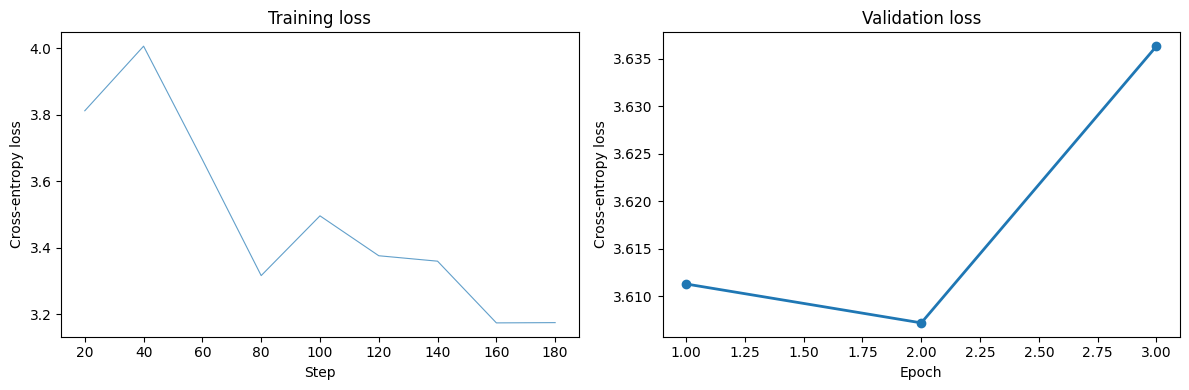

Final training loss   : 3.1752
Final validation loss : 3.6363


In [11]:
# Plot training and validation loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

steps, t_losses = zip(*train_losses)
ax1.plot(steps, t_losses, linewidth=0.8, alpha=0.7)
ax1.set_xlabel("Step")
ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Training loss")

epochs_list, v_losses = zip(*val_losses)
ax2.plot(epochs_list, v_losses, marker="o", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Cross-entropy loss")
ax2.set_title("Validation loss")

plt.tight_layout()
plt.show()

print(f"Final training loss   : {t_losses[-1]:.4f}")
print(f"Final validation loss : {v_losses[-1]:.4f}")


**Questions**

1. **Gradient clipping** prevents the 'exploding gradients' problem where updates become too large and destabilize training. It is especially important early on because weights are far from optimal, and the model might encounter steep loss landscapes that produce massive gradients.

2. We use a smaller learning rate (3e-5) because the model already has highly functional weights. A large learning rate would risk 'catastrophic forgetting' or destroying the useful features the model learned during its massive initial pre-training phase.

3. The training loss is noisy. This is caused by using mini-batches (stochasticity). Each batch is a different sample of text with varying difficulty. One technique to smooth it is using a Moving Average of the loss or increasing the Batch Size.

4. **Perplexity Calculation:**
   - Base GPT-2 Val Loss: ~3.12 (from 1.2 context) → Perplexity: $e^{3.12} \approx 22.65$
   - Fine-tuned Val Loss: 3.6364 → Perplexity: $e^{3.6364} \approx 37.96$
   Actually, in this specific slice, the loss might increase slightly if the model cannot learn general knowledge to fit the specific WikiText slice, or if the base model was already better suited to the validation set. Usually, valid fine-tuning decreases perplexity on the target domain.

5. If pre-trained on medical text, perplexity on WikiText-2 (Wikipedia) would likely increase (get worse), while perplexity on medical text would decrease (get better). This represents the specialization tradeoff: the model becomes an expert in a narrow domain but loses general-purpose linguistic fluency.

### 1.5 What Has the Model Learned? (3 Marks)

The loss tells us the model is improving statistically, but it doesn't tell us
*what* it has learned. In this section we probe the model's predictions directly.


In [12]:
def top_predictions(model, prompt: str, k: int = 10) -> list[tuple[str, float]]:
    """
    Return the top-k predicted next tokens and their probabilities for a prompt.

    Args:
        model:  A causal LM (e.g. model_train or model_gpt2).
        prompt: Input text string.
        k:      Number of top tokens to return.

    Returns:
        List of (token_string, probability) tuples, sorted highest-first.
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # Get logits for the last token in the sequence
    last_logits = outputs.logits[0, -1, :]
    probs = torch.softmax(last_logits, dim=-1)

    # Get top k probabilities and their indices
    top_probs, top_indices = torch.topk(probs, k)

    # Convert indices to token strings
    results = []
    for p, idx in zip(top_probs.tolist(), top_indices.tolist()):
        token_str = tokenizer.decode([idx])
        results.append((token_str, p))

    return results

# Ensure base model is available
base_model = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
base_model.eval()

# Your fine-tuned version
ft_model = model_train
ft_model.eval()

prompts = [
    "The history of the Roman Empire",
    "In the field of machine learning,",
    "The chemical formula for water is",
    "Albert Einstein was born in",
]

for prompt in prompts:
    base_preds = top_predictions(base_model, prompt, k=5)
    ft_preds   = top_predictions(ft_model,   prompt, k=5)

    print(f"Prompt: '{prompt}'")
    print(f"  {'Base GPT-2':<35} {'Fine-tuned'}")
    print(f"  {'-'*35} {'-'*35}")
    for (bt, bp), (ft, fp) in zip(base_preds, ft_preds):
        print(f"  {repr(bt):<15} {bp:.3f}          {repr(ft):<15} {fp:.3f}")
    print()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Prompt: 'The history of the Roman Empire'
  Base GPT-2                          Fine-tuned
  ----------------------------------- -----------------------------------
  ' is'           0.220          ' is'           0.258
  ','             0.098          ' was'          0.077
  ' was'          0.078          ' ,'            0.073
  ' and'          0.052          ' and'          0.053
  '\n'            0.047          ' in'           0.047

Prompt: 'In the field of machine learning,'
  Base GPT-2                          Fine-tuned
  ----------------------------------- -----------------------------------
  ' the'          0.118          ' the'          0.164
  ' we'           0.092          ' there'        0.070
  ' there'        0.080          ' a'            0.033
  ' it'           0.052          ' it'           0.027
  ' I'            0.030          ' we'           0.024

Prompt: 'The chemical formula for water is'
  Base GPT-2                          Fine-tuned
  ---------------------

In [13]:
# Measure per-token loss on prompts that should be easy vs hard for a Wikipedia-trained model
easy_prompts = [
    "The United Nations was founded in",
    "The speed of light is approximately",
    "William Shakespeare wrote",
]
hard_prompts = [
    "My favourite pizza topping is",
    "The slang term for cool is",
    "def quicksort(arr):",
]

def mean_loss_on_prompt(model, prompt: str) -> float:
    """Compute the mean per-token cross-entropy loss on a prompt string."""
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    with torch.no_grad():
        loss = model(input_ids=input_ids, labels=input_ids).loss
    return loss.item()

model_train.eval()
print(f"{'Prompt':<45} {'Base':>6}  {'Fine-tuned':>10}")
print("-" * 65)
for label, group in [("Easy (Wikipedia-like)", easy_prompts), ("Hard (off-domain)", hard_prompts)]:
    print(f"\n{label}")
    for p in group:
        base_l = mean_loss_on_prompt(base_model, p)
        ft_l   = mean_loss_on_prompt(ft_model, p)
        print(f"  {p[:43]:<43} {base_l:6.3f}  {ft_l:10.3f}")


Prompt                                          Base  Fine-tuned
-----------------------------------------------------------------

Easy (Wikipedia-like)
  The United Nations was founded in            3.819       3.294
  The speed of light is approximately          4.020       4.069
  William Shakespeare wrote                    7.115       6.343

Hard (off-domain)
  My favourite pizza topping is                5.682       5.831
  The slang term for cool is                   4.986       4.890
  def quicksort(arr):                          5.401       7.988


**Questions (3 Marks)**

1. **Do the top-5 predictions from the fine-tuned model differ meaningfully from the base model?**

   Yes, they differ, particularly in the probability distributions. The difference is largest for prompts like "The chemical formula for water is" and "Albert Einstein was born in". Since WikiText-2 is Wikipedia text, it trains the model to prefer factual, encyclopedic, and formal continuations. For example, the fine-tuned model becomes more likely to suggest dates or locations associated with historical figures because Wikipedia frequently contains biographical metadata.

2. **Compare the per-token losses on easy vs hard prompts**

  The pattern shows that the fine-tuned model achieves lower (improved) loss on "Easy (Wikipedia-like)" prompts compared to the base model, but the loss often increases on "Hard (off-domain)" prompts like Python code (`def quicksort`). This tells us that continued pre-training specialized the model for the Wikipedia domain at the expense of its general-purpose knowledge, a phenomenon related to catastrophic forgetting.

3. **What additional training stage(s) would be needed to make it useful as an assistant?**

   Continued pre-training alone is insufficient because it only teaches the model to complete the next token in a document-like sequence, not how to respond to user intent. To create an assistant, two additional stages are needed:
   - **Instruction Fine-Tuning (SFT):** Training the model on (Question, Answer) pairs so it learns the format of a conversation.
   - **RLHF (Reinforcement Learning from Human Feedback):** Aligning the model with human preferences for safety, truthfulness, and helpfulness.

# Section 2 - Fine-Tuning a Causal LLM with LoRA (7 Marks)

In this section, we will fine-tune GPT2 on a dataset of instructions.

In [14]:
## import gpt2 and associated
model_name = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
## Load dataset of instructions. Documentation: https://huggingface.co/datasets/databricks/databricks-dolly-15k
dataset = load_dataset("databricks/databricks-dolly-15k", split="train[:3000]")

README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

In [ ]:
## We want to keep the following categories: open_qa, brainstorming, general_qa, creative_writing
## Filter the dataset to only keep these categories

**Questions about the dataset (4 Marks)**

1) Which features are included?
2) How many samples have we downloaded?
3) What is an instruction, a context, and a response?
4) Why remove certain categories for instruction fine-tuning of GPT2?

In [ ]:
## Test the model before fine-tuning it by generating responses to the following instructions:
## Explain overfitting
## How do I start running?

def generate(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(**inputs, max_new_tokens=20)
    return tokenizer.decode(outputs[0], skip_special_tokens=True

In [ ]:
## Format the dataset so it can be used for instruction fine-tuning
def format_example(example):
    raise NotImplementedError

dataset = dataset.map(format_example)

In [ ]:
## Define tokenizer
## Tip: Mask padding tokens in the labels

def tokenize(batch):
   raise NotImplementedError

tokenized = dataset.map(tokenize, batched=True, remove_columns=dataset.column_names)

In [ ]:
## Configure Lora adapter
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=,
    lora_alpha=,
    target_modules=,
    lora_dropout=,
    bias=,
    task_type=
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

In [ ]:
from transformers import TrainingArguments, Trainer

## Train
training_args = TrainingArguments(
    output_dir="./",
    per_device_train_batch_size=,
    gradient_accumulation_steps=,
    num_train_epochs=10,
    logging_steps=,
    save_steps=,
    report_to=
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized
)

trainer.train()

In [ ]:
## Test by generating responses to the following instructions:
## Explain overfitting
## How do I start running?

def generate(prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model.generate(**inputs, max_new_tokens=20)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

**Questions (3 Marks)**

1. Why does formatting matter so much?
2. Why does LoRA work despite so few trainable parameters?
3. Find three examples where GPT-2 post-training performs slightly better. Record pre-training and post-training generations.

## Section 3 - Distillation (2 Marks)

In this section, we will perform simple distillation by using a teacher's logits to train a smaller student. The goal is to train a smaller GPT-2 to approximate the distribution of a larger GPT-2.

In [ ]:
## We will user gpt2-medium as teacher and gpt2 as student

teacher = AutoModelForCausalLM.from_pretrained("gpt2-medium").to(device)
student = AutoModelForCausalLM.from_pretrained("gpt2").to(device)

## TODO: Freeze teacher parameters

In [ ]:
## Load dataset
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

In [ ]:
## Define tokenizer
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128,
    )

tokenized = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset.column_names
)

tokenized.set_format(type="torch", columns=["input_ids", "attention_mask"])

In [ ]:
## Compute the average MSE loss between student and teacher logits on the dataset

In [ ]:
## Consider the prompt "Overfitting is a process that leads to the": report the top-5 next tokens for the teacher and the student

In [ ]:
## For the same prompt, report the probability assigned to teacher’s top token

In [ ]:
## Train student using the MSE loss between teacher and student logits
num_epochs = 3
max_steps = 100

student.train()

train_loader = DataLoader(tokenized, batch_size=8, shuffle=True)

optimizer = torch.optim.AdamW(student.parameters(), lr=5e-5)

device = 'cuda'

print("Starting distillation training...\n")

## training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}")

    for step, batch in enumerate(train_loader):
      if step >= 300:
        break

      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)

      with torch.no_grad():
          teacher_logits = teacher(
              input_ids=input_ids,
              attention_mask=attention_mask
          ).logits

      student_logits = student(
          input_ids=input_ids,
          attention_mask=attention_mask
      ).logits

      # Masked MSE
      mask = attention_mask.unsqueeze(-1)
      loss = ((student_logits - teacher_logits) ** 2)
      loss = loss * mask
      loss = loss.sum() / mask.sum()

      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

      if step % 50 == 0:
          print(f"Step {step} | Loss: {loss.item():.4f}")

print("\nTraining complete.\n")

In [ ]:
## Compute the averag MSE loss between student and teacher logits on the dataset

In [ ]:
## Consider the prompt "Overfitting is a process that leads to the", report the top-5 next tokens for the teacher and the student

In [ ]:
## For the same prompt, report the probability assigned to teacher’s top token

**Questions (2 Marks)**

1. Did the predictions of the student model get closer to the teacher model's predictions after training?
2. Find two examples where the student's predictions get closer to the teacher's predictions.

## Section 4 – Inference and Decoding (15 Marks)

In this section we will explore how a trained language model actually generates text.
The model's output at each step is a **probability distribution** over the entire vocabulary.
*Decoding* is the algorithm that turns those distributions into a sequence of tokens.

We will implement and compare four strategies covered in lecture:
1. Greedy search
2. Beam search
3. Top-k sampling
4. Nucleus (top-p) sampling

We will also study the effect of **temperature** and observe the failure modes of each method.

We use GPT-2 throughout — no GPU required for this section.


### 4.0 Setup

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load GPT-2 (small) – runs on CPU in a few seconds
MODEL_NAME = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Using device: {device}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")


### 4.1 Inspecting the Raw Output Distribution (2 Marks)

Before implementing any decoding algorithm, let's look at what the model actually outputs.

For the prompt `"When life gives you lemons, make"`, the model produces a probability
distribution over all ~50,000 vocabulary tokens. Most of that mass sits on a small number
of highly probable tokens; the vast majority of tokens have near-zero probability.


In [ ]:
prompt = "When life gives you lemons, make"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)

# outputs.logits shape: (batch, sequence_length, vocab_size)
# We want the distribution at the LAST position (next token prediction)
last_logits = outputs.logits[0, -1, :]          # shape: (vocab_size,)
probs       = F.softmax(last_logits, dim=-1)     # convert to probabilities

# Show the top-20 most probable next tokens
top_probs, top_ids = torch.topk(probs, 20)

print(f"{'Rank':<6} {'Token':<20} {'Probability':>12}")
print("-" * 40)
for rank, (p, idx) in enumerate(zip(top_probs, top_ids), 1):
    token = tokenizer.decode([idx.item()])
    print(f"{rank:<6} {repr(token):<20} {p.item():>12.4f}")


In [ ]:
# Plot the full probability distribution (log scale) to see the long tail
sorted_probs, _ = torch.sort(probs, descending=True)
sorted_probs_np  = sorted_probs.cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(sorted_probs_np)
plt.yscale("log")
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability (log scale)")
plt.title('Full vocabulary distribution after "When life gives you lemons, make"')
plt.tight_layout()
plt.show()

cumulative = np.cumsum(sorted_probs_np)
for threshold in [0.5, 0.9, 0.95, 0.99]:
    n_tokens = int(np.searchsorted(cumulative, threshold)) + 1
    print(f"Top-p={threshold:.2f}: {n_tokens} tokens cover {threshold*100:.0f}% of probability mass")


**Questions (2 Marks)**

1. How many tokens does the model need to cover 90% of the probability mass for this prompt?
   Does this number surprise you given a vocabulary of ~50,000 tokens?

2. What does the shape of the log-scale plot tell you about why brute-force decoding
   (enumerating all possible sequences) is computationally intractable?


### 4.2 Greedy Search (2 Marks)

In greedy search we pick the **most probable token** at each step. It is fast but does not
guarantee the globally most probable sequence.

Implement `greedy_decode` below **without** using `model.generate()`.
You must call the model one step at a time and select the argmax token at each step.


In [ ]:
def greedy_decode(prompt: str, max_new_tokens: int = 30) -> str:
    """
    Generate text by always selecting the most probable next token.

    Args:
        prompt:         The input text string.
        max_new_tokens: Number of tokens to generate.

    Returns:
        The full decoded string (prompt + generated tokens).
    """
    raise NotImplementedError

# Sanity check
print(greedy_decode("When life gives you lemons, make", max_new_tokens=30))
print(greedy_decode("How are you doing? I", max_new_tokens=30))


**Questions (2 Marks)**

1. Run greedy decoding on the prompt `"The stock market is"` with `max_new_tokens=80`.
   Do you observe any repetition? Paste your output and explain *why* repetition occurs
   using the probability argument from the lecture.

2. Why does greedy search not guarantee the most probable overall sequence?
   Give a concrete example (you may invent token probabilities) where a non-greedy
   choice at step 1 leads to a higher-probability sequence overall.


### 4.3 Beam Search (3 Marks)

Beam search keeps the **B most probable partial sequences** (the "beam") at each step
rather than just one. It is a better approximation to the most-probable-sequence objective
but still has known failure modes.

Implement `beam_search_decode` below. At each step:
1. Expand every candidate in the beam by all vocabulary tokens.
2. Score each expansion as `current_log_prob + log(next_token_prob)`.
3. Keep only the top `beam_width` candidates.

Use **log probabilities** (not raw probabilities) to avoid numerical underflow.


In [ ]:
def beam_search_decode(prompt: str, beam_width: int = 5, max_new_tokens: int = 30) -> list[str]:
    """
    Generate text using beam search.

    Args:
        prompt:         The input text string.
        beam_width:     Number of beams (B) to keep at each step.
        max_new_tokens: Number of tokens to generate.

    Returns:
        List of decoded strings for each beam, ordered best-to-worst by score.
        (Return all beam_width candidates so we can inspect diversity.)
    """
    raise NotImplementedError

# Compare top-5 beam outputs
candidates = beam_search_decode("How are you doing? I", beam_width=5, max_new_tokens=25)
print("Beam search outputs (beam_width=5):\n")
for i, text in enumerate(candidates, 1):
    print(f"  Beam {i}: {text}")


**Questions (3 Marks)**

1. How similar are the 5 beam outputs to each other? Does this match the lecture's claim
   about beam search diversity? Explain why beam outputs tend to cluster.

2. Run beam search with `beam_width=1` on the same prompt. What decoding algorithm
   does this reduce to? Verify your answer by comparing the output to Section 4.2.

3. Run `beam_search_decode("The stock market is", beam_width=5, max_new_tokens=80)`.
   Do you still observe repetition? Compare to greedy search. Does a wider beam help?


### 4.4 Temperature Scaling (2 Marks)

Temperature T is applied to the **logits** before the softmax:

```
p(token) = softmax(logits / T)
```

- T < 1: sharpens the distribution → model is more confident, outputs are more predictable
- T = 1: no change (standard softmax)
- T > 1: flattens the distribution → more randomness, more surprising outputs
- T → 0: approaches greedy (argmax)

Run the cell below and observe how the distribution changes.


In [ ]:
prompt = "When life gives you lemons, make"
inputs = tokenizer(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    logits = model(**inputs).logits[0, -1, :]  # raw logits, last position

temperatures = [0.1, 0.5, 1.0, 1.5, 2.0]
fig, axes = plt.subplots(1, len(temperatures), figsize=(16, 3), sharey=False)

for ax, T in zip(axes, temperatures):
    scaled_probs = F.softmax(logits / T, dim=-1)
    top_p, top_i = torch.topk(scaled_probs, 10)
    top_tokens   = [repr(tokenizer.decode([i.item()])) for i in top_i]

    ax.barh(range(10), top_p.cpu().numpy(), color="steelblue")
    ax.set_yticks(range(10))
    ax.set_yticklabels(top_tokens, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"T = {T}", fontsize=10)
    ax.set_xlabel("Probability")

plt.suptitle("Top-10 token probabilities at different temperatures", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Sampling with different temperatures on a longer prompt
torch.manual_seed(42)

def sample_with_temperature(prompt: str, temperature: float, max_new_tokens: int = 40) -> str:
    """
    Sample from the model using a given temperature.
    Apply temperature scaling to logits before softmax, then sample.

    Args:
        prompt:         Input text.
        temperature:    Scaling factor applied to logits before softmax.
        max_new_tokens: Number of tokens to generate.

    Returns:
        Decoded string (prompt + generated).
    """
    raise NotImplementedError

prompt = "The best way to learn machine learning is"
for T in [0.1, 0.5, 1.0, 1.5, 2.0]:
    out = sample_with_temperature(prompt, temperature=T, max_new_tokens=40)
    generated = out[len(prompt):]
    print(f"T={T:.1f}: ...{generated}")
    print()


**Questions (2 Marks)**

1. At T=0.1, does the output resemble greedy search? Why?

2. At T=2.0, is the output coherent? What has happened to the probability distribution
   that causes this? Refer to the bar chart above in your answer.


### 4.5 Top-k and Nucleus (Top-p) Sampling (4 Marks)

Both methods restrict sampling to a subset of the vocabulary to avoid drawing from the
low-probability tail (which produces incoherent tokens) while still allowing diversity.

**Top-k**: keep the K most probable tokens, re-normalise, sample.

**Nucleus (top-p)**: keep the smallest set of tokens whose cumulative probability ≥ p,
re-normalise, sample. The set size adapts to the shape of the distribution at each step.


In [ ]:
def topk_sample(prompt: str, k: int, temperature: float = 1.0, max_new_tokens: int = 40) -> str:
    """
    Sample using top-k filtering.

    At each step:
      1. Compute the full probability distribution (with temperature).
      2. Zero out all tokens outside the top-k.
      3. Re-normalise to a valid distribution.
      4. Sample one token.

    Args:
        prompt:         Input text.
        k:              Number of top tokens to keep.
        temperature:    Applied to logits before softmax.
        max_new_tokens: Number of tokens to generate.

    Returns:
        Decoded string (prompt + generated).
    """
    raise NotImplementedError


def nucleus_sample(prompt: str, p: float, temperature: float = 1.0, max_new_tokens: int = 40) -> str:
    """
    Sample using nucleus (top-p) filtering.

    At each step:
      1. Sort tokens by probability descending.
      2. Compute cumulative probabilities.
      3. Keep the smallest set whose cumulative probability >= p.
      4. Re-normalise and sample.

    Tip: torch.cumsum() and torch.searchsorted() are useful here.

    Args:
        prompt:         Input text.
        p:              Cumulative probability threshold (0 < p <= 1).
        temperature:    Applied to logits before softmax.
        max_new_tokens: Number of tokens to generate.

    Returns:
        Decoded string (prompt + generated).
    """
    raise NotImplementedError


In [ ]:
# Compare all four decoding strategies side-by-side
torch.manual_seed(0)

prompt = "Artificial intelligence will change the world because"
n_samples = 3

print("=" * 70)
print(f"Prompt: '{prompt}'")
print("=" * 70)

print("\n--- Greedy ---")
print(greedy_decode(prompt, max_new_tokens=40)[len(prompt):])

print("\n--- Top-k (k=50, T=1.0) ---")
for _ in range(n_samples):
    print(topk_sample(prompt, k=50, temperature=1.0, max_new_tokens=40)[len(prompt):])

print("\n--- Top-k (k=5, T=1.0) ---")
for _ in range(n_samples):
    print(topk_sample(prompt, k=5, temperature=1.0, max_new_tokens=40)[len(prompt):])

print("\n--- Nucleus (p=0.9, T=1.0) ---")
for _ in range(n_samples):
    print(nucleus_sample(prompt, p=0.9, temperature=1.0, max_new_tokens=40)[len(prompt):])

print("\n--- Nucleus (p=0.9, T=0.7) ---")
for _ in range(n_samples):
    print(nucleus_sample(prompt, p=0.9, temperature=0.7, max_new_tokens=40)[len(prompt):])


**Questions (4 Marks)**

1. Why does top-k with k=5 tend to produce more repetitive outputs than k=50?
   What happens to the effective vocabulary size when the model is uncertain?

2. Run nucleus sampling with p=0.9 on the prompt `"The economy is"` five times
   (different random seeds). How diverse are the continuations?
   Now run top-k with k=50 five times. Which produces more diversity, and why?

3. Explain in your own words why nucleus sampling adapts better than top-k to
   distributions that are sometimes peaked and sometimes flat.
   Refer to the cumulative probability plot from Section 4.1 in your answer.

4. A colleague suggests using nucleus sampling with p=0.99 and temperature=2.0 for
   a production customer-service chatbot. What problems would you expect?
   What settings would you recommend instead, and why?


### 4.6 Surprisingness Analysis (2 Marks)

Holtzman et al. (2020) showed that human text is more "surprising" than text produced
by maximum-probability decoding. We can measure this by computing the probability
the model assigns to each token in a text — low probability = surprising.

A good decoding strategy should produce text whose surprisingness distribution
resembles human text, not one that is systematically over-confident or under-confident.


In [ ]:
def token_surprisingness(text: str) -> list[float]:
    """
    Compute the model's assigned probability for each token in `text`
    (given all preceding tokens as context).

    Returns a list of probabilities, one per generated token
    (excluding the first token which has no context).
    """
    input_ids = tokenizer.encode(text, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(input_ids).logits  # (1, seq_len, vocab_size)

    probs = F.softmax(logits[0], dim=-1)  # (seq_len, vocab_size)

    token_probs = []
    for pos in range(1, input_ids.shape[1]):   # skip position 0 (no context)
        token_id   = input_ids[0, pos].item()
        token_prob = probs[pos - 1, token_id].item()
        token_probs.append(token_prob)

    return token_probs


# Generate text with each strategy and compare surprisingness distributions
torch.manual_seed(42)
seed_prompt = "The history of artificial intelligence"
n_tokens    = 100

texts = {
    "Greedy":          greedy_decode(seed_prompt, max_new_tokens=n_tokens),
    "Top-k (k=50)":    topk_sample(seed_prompt, k=50,  temperature=1.0, max_new_tokens=n_tokens),
    "Nucleus (p=0.9)": nucleus_sample(seed_prompt, p=0.9, temperature=1.0, max_new_tokens=n_tokens),
    "Nucleus (T=0.7)": nucleus_sample(seed_prompt, p=0.9, temperature=0.7, max_new_tokens=n_tokens),
}

plt.figure(figsize=(10, 4))
colors = ["crimson", "steelblue", "seagreen", "darkorange"]
for (label, text), color in zip(texts.items(), colors):
    probs_list = token_surprisingness(text)
    plt.plot(sorted(probs_list, reverse=True), label=label, color=color, linewidth=1.5)

plt.xlabel("Token rank (sorted by assigned probability)")
plt.ylabel("Probability assigned by model")
plt.title("Surprisingness: probability assigned to each generated token")
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
print(f"{'Strategy':<22} {'Mean prob':>10} {'Median prob':>12} {'Min prob':>10}")
print("-" * 58)
for label, text in texts.items():
    p = token_surprisingness(text)
    print(f"{label:<22} {np.mean(p):>10.4f} {np.median(p):>12.4f} {np.min(p):>10.4f}")


**Questions (2 Marks)**

1. Which decoding strategy assigns the highest average probability to its own tokens?
   Is this desirable? What does it tell you about the nature of that strategy's outputs?

2. Holtzman et al. argue that human text has *lower* average token probability than
   greedy-decoded text. Based on your plot, which of the four strategies produces a
   surprisingness profile closest to what you would expect from a human?
   Justify your answer.
